Recommended sources to bookmark
Belgium: ODWB — Communes/Gemeente - Vintage/Millésimé - Belgium.
Belgium secondary: ODWB — Code Postaux Belges.
Moldova: BNS — CUATM, including downloadable Excel.
Moldova geometry: geoBoundaries / HDX Moldova ADM1.
Weather: Open-Meteo Forecast API.
Optional geocoding: Open-Meteo Geocoding API.

Next step should be very small: we make the first Python requests call to the ODWB municipality API, inspect the returned JSON together, and extract only name + latitude + longitude. Only after that do we connect it to Open-Meteo. This matches exactly the requests module you are studying now.

EXO Call API:
fetch the meteo prevision (7days) (see above)
for all communes of brussels (via open database of Wallonia: odbw)
https://www.odwb.be/explore/dataset/communes-belges0/table/ 
https://www.odwb.be/api/records/1.0/search/?dataset=code-postaux-belge&q=&facet=column_1&facet=column_2

In [54]:
import requests
# Import Pandas.
import pandas as pd
# This is the address of the Belgian communes dataset API.
url = "https://www.odwb.be/api/explore/v2.1/catalog/datasets/communes-gemeente-vintage-millesime-belgium/records"

# We ask the API to return only 2 records.
# This keeps our first experiment small and easy to inspect.
params = {
    "limit": 2
}

# requests.get() sends an HTTP GET request to the API.
# timeout=20 means Python will stop waiting after 20 seconds
# if the server does not answer.
response = requests.get(url, params=params, timeout=20)

# Show the exact URL Python finally sent.
print("URL sent:")
print(response.url)

# Show the HTTP status code.
print("\nStatus code:")
print(response.status_code)

URL sent:
https://www.odwb.be/api/explore/v2.1/catalog/datasets/communes-gemeente-vintage-millesime-belgium/records?limit=2

Status code:
200


In [5]:
# Convert the JSON returned by ODWB into Python data.
data = response.json()

# Check the Python type.
print(type(data))

# Show the top-level keys available in the API response.
print(data.keys())

# Show how many records exist in the complete dataset.
print("Total records:", data["total_count"])

# Show how many records we asked Python to retrieve this time.
print("Records received:", len(data["results"]))

<class 'dict'>
dict_keys(['total_count', 'results'])
Total records: 4051
Records received: 2


In [16]:
# Take only the first commune record returned by the API.
first_commune = data["results"][0]

print(first_commune)

# Check the Python type of one commune record.
print(type(first_commune))

# Show the names of all fields available for one commune.
print(first_commune.keys())
print("_"*50)

first_commune["mun_name_fr"]

print("_"*50)

commune_name = first_commune["mun_name_fr"][0]

print("_"*50)
print(commune_name)

# Extract the geographic coordinates of the commune.
latitude = first_commune["geo_point_2d"]["lat"]
longitude = first_commune["geo_point_2d"]["lon"]

print("Commune:", commune_name)
print("Latitude:", latitude)
print("Longitude:", longitude)

{'geo_point_2d': {'lon': 5.966473841178134, 'lat': 50.530835382978985}, 'geo_shape': {'type': 'Feature', 'geometry': {'coordinates': [[[6.072822834000021, 50.519734424000035], [6.072879098000044, 50.52105639800004], [6.072822019000057, 50.525963930000046], [6.069138982000027, 50.52846190900004], [6.06428769200005, 50.53169549200004], [6.062470034000057, 50.53317211500007], [6.057835703000023, 50.53701852100005], [6.057439571000032, 50.53769368400003], [6.057173555000077, 50.53798947400003], [6.056335709000052, 50.538454021000064], [6.056122387000073, 50.53864387800007], [6.056076956000027, 50.539056885000036], [6.055826502000059, 50.539374819000045], [6.055101071000024, 50.53996520600003], [6.054550071000051, 50.54095684400005], [6.054120108000063, 50.54114152200003], [6.053873787000043, 50.54144267500004], [6.053530597000076, 50.54216512200003], [6.052954638000074, 50.542676752000034], [6.052453969000055, 50.54302202700006], [6.051811569000051, 50.54374244500008], [6.051868981000041, 

In [26]:
# Open-Meteo weather forecast API address.
weather_url = "https://api.open-meteo.com/v1/forecast"

# These are the parameters we send to Open-Meteo.
# We reuse the latitude and longitude extracted from ODWB.
weather_params = {
    "latitude": latitude,
    "longitude": longitude,
    "daily": "temperature_2m_max,temperature_2m_min",
    "timezone": "auto",
    "forecast_days": 7
}

# Send the GET request to Open-Meteo.
weather_response = requests.get(
    weather_url,
    params=weather_params,
    timeout=20
)

# Check whether the request succeeded.
print("Status code:", weather_response.status_code)
print(weather_response.url)

# Convert the JSON returned by Open-Meteo into Python data.
weather_data = weather_response.json()

# Check what type of Python object we received.
print(type(weather_data))

print(weather_data)
# Show the main keys available in the weather response.
print(weather_data.keys())

# Show which variables are available inside the daily forecast.
print(weather_data["daily"].keys())

# Count how many forecast dates Open-Meteo returned.
number_of_days = len(weather_data["daily"]["time"])

print("Number of forecast days:", number_of_days)

Status code: 200
https://api.open-meteo.com/v1/forecast?latitude=50.530835382978985&longitude=5.966473841178134&daily=temperature_2m_max%2Ctemperature_2m_min&timezone=auto&forecast_days=7
<class 'dict'>
{'latitude': 50.548, 'longitude': 5.974, 'generationtime_ms': 0.07402896881103516, 'utc_offset_seconds': 7200, 'timezone': 'Europe/Brussels', 'timezone_abbreviation': 'GMT+2', 'elevation': 323.0, 'daily_units': {'time': 'iso8601', 'temperature_2m_max': '°C', 'temperature_2m_min': '°C'}, 'daily': {'time': ['2026-08-18', '2026-08-19', '2026-08-20', '2026-08-21', '2026-08-22', '2026-08-23', '2026-08-24'], 'temperature_2m_max': [17.5, 17.8, 19.7, 20.5, 19.8, 17.7, 20.4], 'temperature_2m_min': [13.6, 13.8, 13.4, 13.4, 12.2, 11.5, 11.3]}}
dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])
dict_keys(['time', 'temperature_2m_max', 'temperature_2m_min'])
Number of forecast days: 7


In [ ]:
# Extract the 7 forecast dates.
dates = weather_data["daily"]["time"]

# Extract the maximum temperature for each date.
temp_max = weather_data["daily"]["temperature_2m_max"]

# Extract the minimum temperature for each date.
temp_min = weather_data["daily"]["temperature_2m_min"]

# Display the extracted data.
print("Dates:", dates)
print("Maximum temperatures:", temp_max)
print("Minimum temperatures:", temp_min)

# Display only the first forecast day.
print("Commune:", commune_name)
print("Date:", dates[0])
print("Minimum:", temp_min[0], "°C")
print("Maximum:", temp_max[0], "°C")



Dates: ['2026-08-18', '2026-08-19', '2026-08-20', '2026-08-21', '2026-08-22', '2026-08-23', '2026-08-24']
Maximum temperatures: [17.5, 17.8, 19.7, 20.5, 19.8, 17.7, 20.4]
Minimum temperatures: [13.6, 13.8, 13.4, 13.4, 12.2, 11.5, 11.3]
Commune: Jalhay
Date: 2026-08-18
Minimum: 13.6 °C
Maximum: 17.5 °C


In [39]:
# This loop goes through every forecast day.
# i will successively take the values 0, 1, 2, 3, 4, 5 and 6.

for i in range(len(dates)):
    print(
        commune_name,
        "-",
        dates[i],
        "- min:",
        temp_min[i],
        "°C",
        "- max:",
        temp_max[i],
        "°C"
    )


    # This empty list will contain all forecast records.
forecast_records = []

# This loop creates one structured record for each forecast day.

for i in range(len(dates)):
    record = {
        "commune": commune_name,
        "date": dates[i],
        "temp_min": temp_min[i],
        "temp_max": temp_max[i]
    }

    forecast_records.append(record)

print(forecast_records)
print(forecast_records[0])
print("Number of records:", len(forecast_records))


Jalhay - 2026-08-18 - min: 13.6 °C - max: 17.5 °C
Jalhay - 2026-08-19 - min: 13.8 °C - max: 17.8 °C
Jalhay - 2026-08-20 - min: 13.4 °C - max: 19.7 °C
Jalhay - 2026-08-21 - min: 13.4 °C - max: 20.5 °C
Jalhay - 2026-08-22 - min: 12.2 °C - max: 19.8 °C
Jalhay - 2026-08-23 - min: 11.5 °C - max: 17.7 °C
Jalhay - 2026-08-24 - min: 11.3 °C - max: 20.4 °C
[{'commune': 'Jalhay', 'date': '2026-08-18', 'temp_min': 13.6, 'temp_max': 17.5}, {'commune': 'Jalhay', 'date': '2026-08-19', 'temp_min': 13.8, 'temp_max': 17.8}, {'commune': 'Jalhay', 'date': '2026-08-20', 'temp_min': 13.4, 'temp_max': 19.7}, {'commune': 'Jalhay', 'date': '2026-08-21', 'temp_min': 13.4, 'temp_max': 20.5}, {'commune': 'Jalhay', 'date': '2026-08-22', 'temp_min': 12.2, 'temp_max': 19.8}, {'commune': 'Jalhay', 'date': '2026-08-23', 'temp_min': 11.5, 'temp_max': 17.7}, {'commune': 'Jalhay', 'date': '2026-08-24', 'temp_min': 11.3, 'temp_max': 20.4}]
{'commune': 'Jalhay', 'date': '2026-08-18', 'temp_min': 13.6, 'temp_max': 17.5}
Nu

In [93]:
# This function receives:
# - the commune name
# - its latitude
# - its longitude
#
# It calls Open-Meteo and returns 7 structured forecast records.

def get_weather(commune_name, latitude, longitude):

    weather_url = "https://api.open-meteo.com/v1/forecast"

    weather_params = {
        "latitude": latitude,
        "longitude": longitude,
         "daily": (
            "temperature_2m_max,"
            "temperature_2m_min,"
            "precipitation_sum,"
            "precipitation_probability_max,"
            "weather_code"
        ),
        "timezone": "auto",
        "forecast_days": 7
    }

    weather_response = requests.get(
        weather_url,
        params=weather_params,
        timeout=20
    )
 # Convert the JSON response into Python data.
    weather_data = weather_response.json()
   # Extract the daily lists.
    dates = weather_data["daily"]["time"]
    temp_max = weather_data["daily"]["temperature_2m_max"]
    temp_min = weather_data["daily"]["temperature_2m_min"]
    precipitation = weather_data["daily"]["precipitation_sum"]
    precipitation_probability = weather_data["daily"]["precipitation_probability_max"]
    weather_codes = weather_data["daily"]["weather_code"]

    forecast_records = []

    for i in range(len(dates)):

        record = {
            "commune": commune_name,
            "date": dates[i],
            "temp_min": temp_min[i],
            "temp_max": temp_max[i],
            "precipitation_mm": precipitation[i],
            "precipitation_probability": precipitation_probability[i],
            "weather_code": weather_codes[i]
        }

        forecast_records.append(record)

    return forecast_records

In [95]:
# Test our new reusable function with Jalhay.

jalhay_forecast = get_weather(
    commune_name,
    latitude,
    longitude
)

print(jalhay_forecast[0])

# Confirm that the function returned 7 days.
print("Number of records:", len(jalhay_forecast))

# Take the second commune returned by ODWB.
second_commune = data["results"][1]

print(second_commune["mun_name_fr"])

# Extract the second commune name.
second_commune_name = second_commune["mun_name_fr"][0]

# Extract its coordinates.
second_latitude = second_commune["geo_point_2d"]["lat"]
second_longitude = second_commune["geo_point_2d"]["lon"]

print("Commune:", second_commune_name)
print("Latitude:", second_latitude)
print("Longitude:", second_longitude)

# Call the same reusable weather function
# for the second commune.

second_forecast = get_weather(
    second_commune_name,
    second_latitude,
    second_longitude
)

print(second_forecast[0])

print("Number of forecast records:", len(second_forecast))

{'commune': 'Soignies', 'date': '2026-08-18', 'temp_min': 15.8, 'temp_max': 19.8, 'precipitation_mm': 6.9, 'precipitation_probability': 100, 'weather_code': 63}
Number of records: 7
['Soignies']
Commune: Soignies
Latitude: 50.566142488244886
Longitude: 4.0383384133391615
{'commune': 'Soignies', 'date': '2026-08-18', 'temp_min': 15.8, 'temp_max': 19.8, 'precipitation_mm': 6.9, 'precipitation_probability': 100, 'weather_code': 63}
Number of forecast records: 7


In [96]:


# Start with an empty list.
# This prevents duplicate records when we rerun the cell.
all_forecasts = []


# Go through every commune returned by ODWB.
for commune in data["results"]:

    # Select a commune name.
    # Some communes may have a French, Dutch or German name,
    # so we use the first available one.

    names = (
        commune["mun_name_fr"]
        or commune["mun_name_nl"]
        or commune["mun_name_de"]
    )

    commune_name = names[0]

    # Extract coordinates from ODWB.
    latitude = commune["geo_point_2d"]["lat"]
    longitude = commune["geo_point_2d"]["lon"]

    # Ask Open-Meteo for this commune's 7-day forecast.
    commune_forecast = get_weather(
        commune_name,
        latitude,
        longitude
    )

    # Add the 7 forecast records to our global list.
    all_forecasts.extend(commune_forecast)

    # Check how many weather records were created.

print("Total forecast records:", len(all_forecasts))
# Show the first forecast record.
print("\nFirst record:")
print(all_forecasts[0])
# Show the last forecast record.
print("\nLast record:")
print("\nLast record:")

print(all_forecasts[-1])
# Display all records in a simple readable format.
print("\nAll forecasts:")
for record in all_forecasts:
    print(
        record["commune"],
        record["date"],
        record["temp_min"],
        record["temp_max"]
    )

Total forecast records: 14

First record:
{'commune': 'Jalhay', 'date': '2026-08-18', 'temp_min': 13.6, 'temp_max': 17.4, 'precipitation_mm': 6.6, 'precipitation_probability': 100, 'weather_code': 61}

Last record:

Last record:
{'commune': 'Soignies', 'date': '2026-08-24', 'temp_min': 11.6, 'temp_max': 20.3, 'precipitation_mm': 0.0, 'precipitation_probability': 27, 'weather_code': 2}

All forecasts:
Jalhay 2026-08-18 13.6 17.4
Jalhay 2026-08-19 14.7 18.2
Jalhay 2026-08-20 13.3 18.9
Jalhay 2026-08-21 12.7 19.5
Jalhay 2026-08-22 11.1 19.5
Jalhay 2026-08-23 12.1 17.8
Jalhay 2026-08-24 11.2 19.6
Soignies 2026-08-18 15.8 19.8
Soignies 2026-08-19 15.3 19.2
Soignies 2026-08-20 15.0 21.2
Soignies 2026-08-21 13.6 19.5
Soignies 2026-08-22 10.5 20.5
Soignies 2026-08-23 12.6 20.1
Soignies 2026-08-24 11.6 20.3


In [ ]:
# Convert the list of forecast dictionaries into a DataFrame.
df_weather = pd.DataFrame(all_forecasts)

# Display the table.
print(df_weather)
print("_"*50)
print(df_weather.shape)
print("_"*50)
# Show how Pandas currently understands each column.
print(df_weather.dtypes)
#Check the column names
print(df_weather.columns)

# Convert the date column from text into a real datetime type.
df_weather["date"] = pd.to_datetime(df_weather["date"])

print(df_weather.dtypes)
print("_"*50)
df_weather = pd.DataFrame(all_forecasts)
print(df_weather.shape)
print("_"*50)
print(df_weather.dtypes)
print("_"*50)

     commune        date  temp_min  temp_max  precipitation_mm  \
0     Jalhay  2026-08-18      13.6      17.4               6.6   
1     Jalhay  2026-08-19      14.7      18.2               4.0   
2     Jalhay  2026-08-20      13.3      18.9               3.7   
3     Jalhay  2026-08-21      12.7      19.5               3.2   
4     Jalhay  2026-08-22      11.1      19.5               0.9   
5     Jalhay  2026-08-23      12.1      17.8               3.3   
6     Jalhay  2026-08-24      11.2      19.6               1.5   
7   Soignies  2026-08-18      15.8      19.8               6.9   
8   Soignies  2026-08-19      15.3      19.2               3.0   
9   Soignies  2026-08-20      15.0      21.2               2.0   
10  Soignies  2026-08-21      13.6      19.5              11.5   
11  Soignies  2026-08-22      10.5      20.5               0.9   
12  Soignies  2026-08-23      12.6      20.1               0.3   
13  Soignies  2026-08-24      11.6      20.3               0.0   

    preci

ODWB API
   ↓
requests
   ↓
commune coordinates
   ↓
Open-Meteo API
   ↓
Python dictionaries
   ↓
Pandas DataFrame
   ↓
proper data types

In [104]:
# This dictionary translates Open-Meteo / WMO weather codes
# into descriptions that a person can understand.

weather_descriptions = {
    0: "Clear sky",

    1: "Mainly clear",
    2: "Partly cloudy",
    3: "Overcast",

    45: "Fog",
    48: "Rime fog",

    51: "Light drizzle",
    53: "Moderate drizzle",
    55: "Dense drizzle",

    56: "Light freezing drizzle",
    57: "Dense freezing drizzle",

    61: "Light rain",
    63: "Moderate rain",
    65: "Heavy rain",

    66: "Light freezing rain",
    67: "Heavy freezing rain",

    71: "Light snow",
    73: "Moderate snow",
    75: "Heavy snow",

    77: "Snow grains",

    80: "Light rain showers",
    81: "Moderate rain showers",
    82: "Heavy rain showers",

    85: "Light snow showers",
    86: "Heavy snow showers",

    95: "Thunderstorm",
    96: "Thunderstorm with light hail",
    99: "Thunderstorm with heavy hail"
}

In [106]:
# Convert the date column to a real datetime type.
df_weather["date"] = pd.to_datetime(df_weather["date"])

# Sort first by commune, then by date.
df_weather = df_weather.sort_values(
    by=["commune", "date"]
)

df_weather

# Ask the dictionary what weather code 61 means.
print(weather_descriptions[61])
print(weather_descriptions[0])

Light rain
Clear sky


In [110]:
# Translate every numerical weather code
# and create a new readable column.

df_weather["weather"] = df_weather["weather_code"].map(
    weather_descriptions
)

df_weather

print(df_weather.shape)

# Display a cleaner selection of columns.
df_weather[
    [
        "commune",
        "date",
        "temp_min",
        "temp_max",
        "precipitation_mm",
        "precipitation_probability",
        "weather"
    ]
]

(14, 8)


,commune,date,temp_min,temp_max,precipitation_mm,precipitation_probability,weather
0,Jalhay,2026-08-18,13.6,17.4,6.6,100,Light rain
1,Jalhay,2026-08-19,14.7,18.2,4.0,95,Light rain
2,Jalhay,2026-08-20,13.3,18.9,3.7,64,Moderate rain
3,Jalhay,2026-08-21,12.7,19.5,3.2,85,Moderate drizzle
4,Jalhay,2026-08-22,11.1,19.5,0.9,46,Light drizzle
5,Jalhay,2026-08-23,12.1,17.8,3.3,29,Moderate drizzle
6,Jalhay,2026-08-24,11.2,19.6,1.5,33,Light drizzle
7,Soignies,2026-08-18,15.8,19.8,6.9,100,Moderate rain
8,Soignies,2026-08-19,15.3,19.2,3.0,71,Light rain
9,Soignies,2026-08-20,15.0,21.2,2.0,82,Light rain


Selected commune: Jalhay


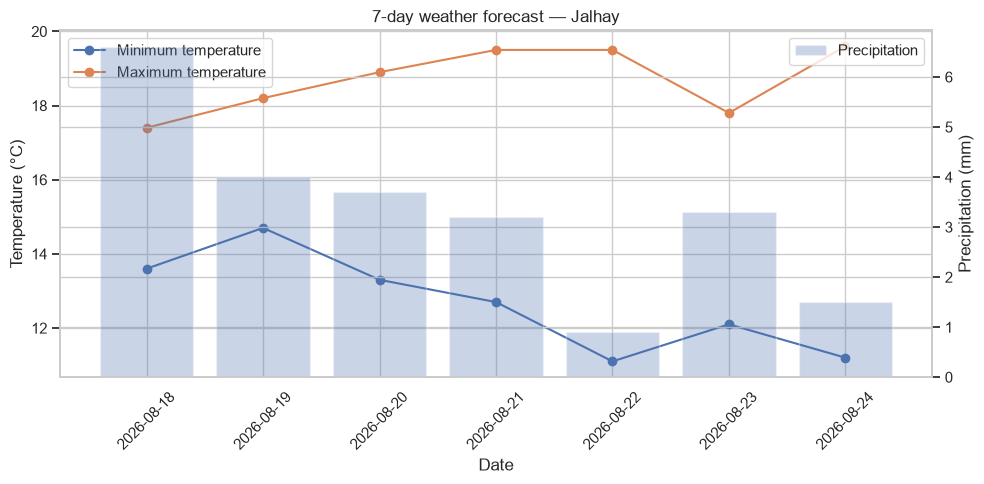

In [113]:
# Take the name of the first commune in our DataFrame.
selected_commune = df_weather["commune"].iloc[0]

# Keep only the rows for that commune.
# Then sort them chronologically by date.
df_commune = (
    df_weather[df_weather["commune"] == selected_commune]
    .sort_values("date")
)

print("Selected commune:", selected_commune)

df_commune

# Import Matplotlib.
import matplotlib.pyplot as plt


# Create the figure and the first axis.
# ax1 will be used for temperature.
fig, ax1 = plt.subplots(figsize=(10, 5))


# Plot minimum temperature.
ax1.plot(
    df_commune["date"],
    df_commune["temp_min"],
    marker="o",
    label="Minimum temperature"
)


# Plot maximum temperature.
ax1.plot(
    df_commune["date"],
    df_commune["temp_max"],
    marker="o",
    label="Maximum temperature"
)


# Label the first Y-axis.
ax1.set_ylabel("Temperature (°C)")

# Label the X-axis.
ax1.set_xlabel("Date")


# Create a second Y-axis.
# It shares the same dates on the X-axis.
ax2 = ax1.twinx()


# Plot daily precipitation as bars.
ax2.bar(
    df_commune["date"],
    df_commune["precipitation_mm"],
    alpha=0.3,
    label="Precipitation"
)


# Label the second Y-axis.
ax2.set_ylabel("Precipitation (mm)")


# Add the title.
plt.title(
    f"7-day weather forecast — {selected_commune}"
)


# Rotate the dates to make them easier to read.
ax1.tick_params(
    axis="x",
    rotation=45
)


# Add legends for both axes.
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")


# Prevent labels from overlapping.
plt.tight_layout()


# Display the chart.
plt.show()

<Figure size 900x500 with 0 Axes>

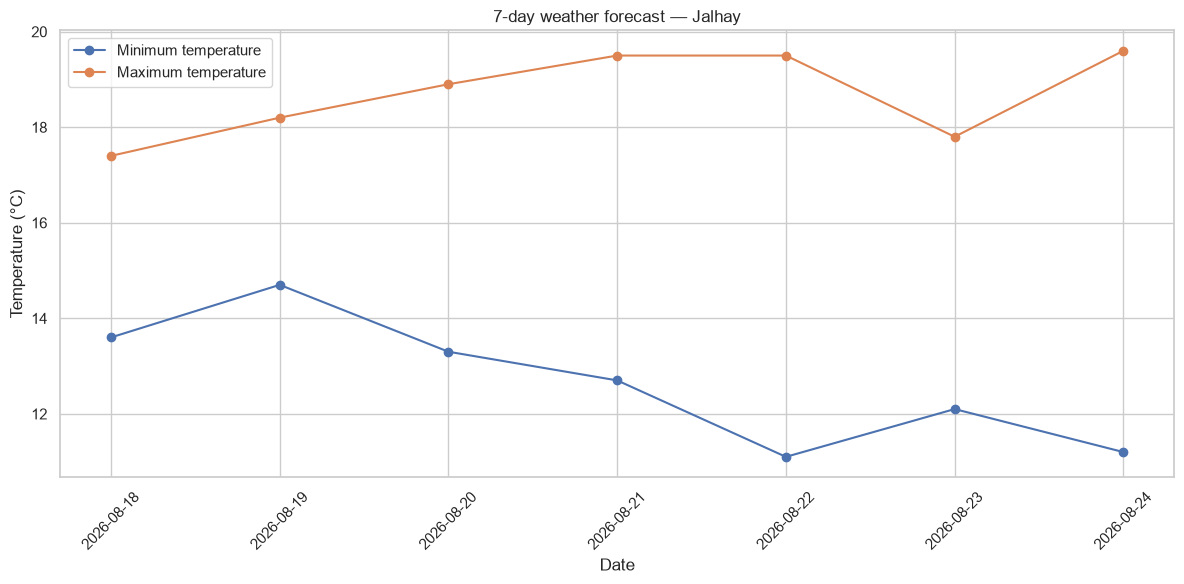

<Figure size 900x500 with 0 Axes>

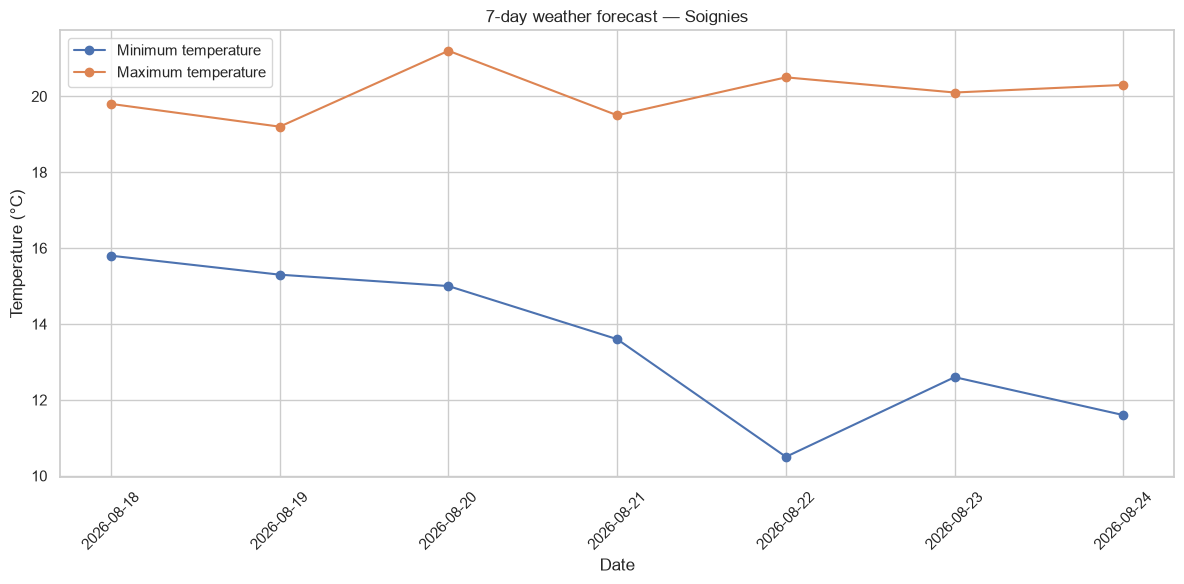


COMMUNE: Jalhay
  commune       date  temp_min  temp_max  precipitation_mm  \
0  Jalhay 2026-08-18      13.6      17.4               6.6   
1  Jalhay 2026-08-19      14.7      18.2               4.0   
2  Jalhay 2026-08-20      13.3      18.9               3.7   
3  Jalhay 2026-08-21      12.7      19.5               3.2   
4  Jalhay 2026-08-22      11.1      19.5               0.9   
5  Jalhay 2026-08-23      12.1      17.8               3.3   
6  Jalhay 2026-08-24      11.2      19.6               1.5   

   precipitation_probability  weather_code           weather  
0                        100            61        Light rain  
1                         95            61        Light rain  
2                         64            63     Moderate rain  
3                         85            53  Moderate drizzle  
4                         46            51     Light drizzle  
5                         29            53  Moderate drizzle  
6                         33            51   

In [111]:
# Import Matplotlib.
import matplotlib.pyplot as plt
import seaborn as sns

# groupby("commune") separates the DataFrame
# into one small DataFrame for each commune.
for commune, data_commune in df_weather.groupby("commune"):

    
    # Create a new figure for this commune.
    plt.figure(figsize=(9, 5))
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))



    # Plot minimum temperature.
    plt.plot(
        data_commune["date"],
        data_commune["temp_min"],
        marker="o",
        label="Minimum temperature"
    )

    # Plot maximum temperature.
    plt.plot(
        data_commune["date"],
        data_commune["temp_max"],
        marker="o",
        label="Maximum temperature"
    )

    # Add chart information.
    plt.title(f"7-day weather forecast — {commune}")
    plt.xlabel("Date")
    plt.ylabel("Temperature (°C)")

    # Show which line is min and which is max.
    plt.legend()

    # Make dates easier to read.
    plt.xticks(rotation=45)

    # Prevent labels from overlapping.
    plt.tight_layout()
    

    # Display the chart.
    plt.show()

    # Look at how Pandas grouped the communes.
for commune, data_commune in df_weather.groupby("commune"):
    print("\nCOMMUNE:", commune)
    print(data_commune)

In [112]:
# This is a temporary test request.
# We keep the existing get_weather() function unchanged for now.

test_weather_url = "https://api.open-meteo.com/v1/forecast"

test_weather_params = {
    "latitude": latitude,
    "longitude": longitude,
    "daily": (
        "temperature_2m_max,"
        "temperature_2m_min,"
        "precipitation_sum,"
        "precipitation_probability_max,"
        "weather_code"
    ),
    "timezone": "auto",
    "forecast_days": 7
}

# Send the test request to Open-Meteo.
test_weather_response = requests.get(
    test_weather_url,
    params=test_weather_params,
    timeout=20
)

print("Status code:", test_weather_response.status_code)

# Convert the returned JSON into a Python dictionary.
test_weather_data = test_weather_response.json()

print(test_weather_data["daily"].keys())

Status code: 200
dict_keys(['time', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'precipitation_probability_max', 'weather_code'])
